# WandB Multi-Run Plotting

This notebook extracts metrics from multiple Weights & Biases runs and plots them together.

In [133]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

In [134]:
# Configuration
ENTITY = "aml-fl-project"  # e.g. username or team
PROJECT = "fl-task-arithmetic"  # project name
METRIC = "accuracy"  # metric to plot
X_AXIS = "epoch"

In [136]:
api = wandb.Api()
runs = api.runs(f"{ENTITY}/{PROJECT}")
print(f"Found {len(runs)} runs")

Found 92 runs


In [137]:
records = []

for run in runs:
    try:
        hist = run.history(keys=[METRIC], pandas=True)
        hist = hist.dropna(subset=[METRIC])
        hist["run_name"] = run.group
        records.append(hist[[METRIC, "run_name"]])
    except Exception as e:
        # print(f"Skipping {run.name}: {e}")
        continue

df = pd.concat(records)
df[X_AXIS] = df.groupby("run_name").cumcount()

# 1. Define which runs need trimming and how many initial epochs to skip
# Format: "run_name_from_wandb_group": number_of_epochs_to_skip
skip_epochs_config = {
    "baseline-fedavg-nc1-j4": 3,
    "baseline-fedavg-nc10-j4": 1,
    "baseline-fedavg-nc100-j8": 6,
    "baseline-fedavg-nc50-j8": 1,
    "baseline-fedavg-nc10-j8": 1,
    "baseline-fedavg-nc50-j16": 1,
    "baseline-fedavg-nc5-j16": 1,
}

# 2. Filter the DataFrame
for run_name, skip_count in skip_epochs_config.items():
    df = df[~((df["run_name"] == run_name) & (df["epoch"] < skip_count))]

df[X_AXIS] = df.groupby("run_name").cumcount() + 1

# Baselines

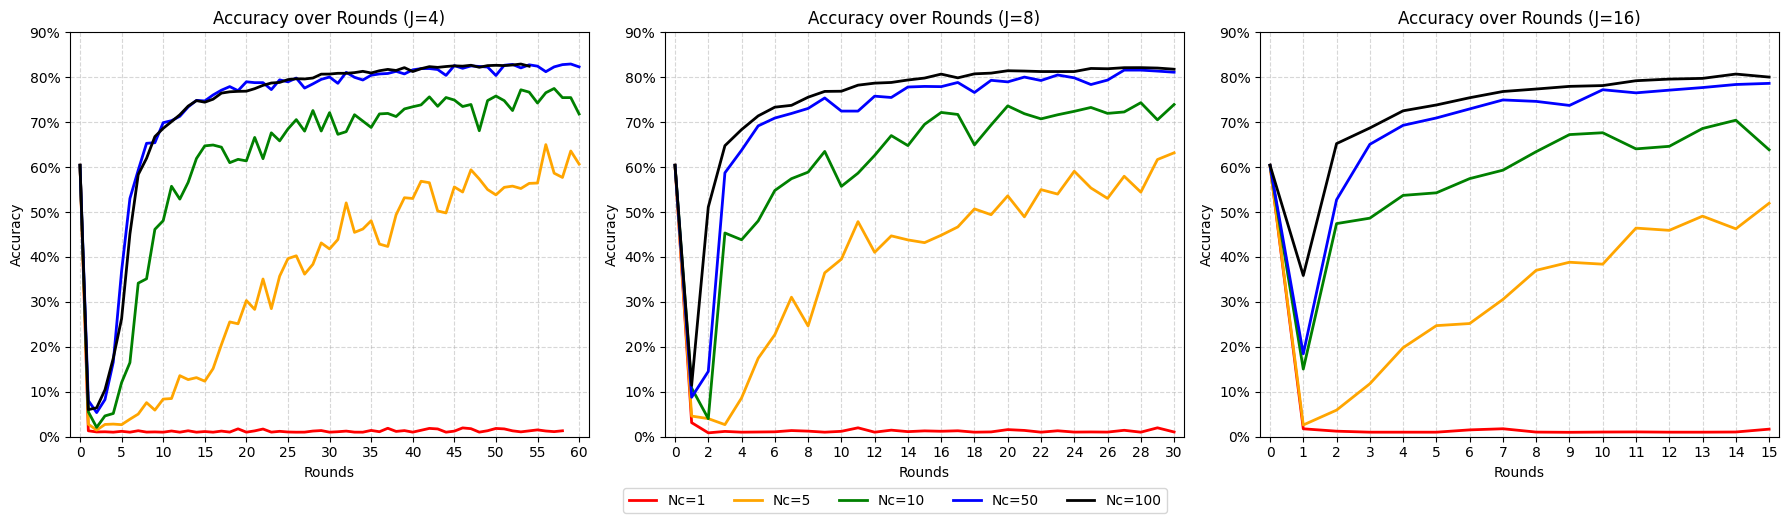

In [138]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Configuration
METRIC = "accuracy"
X_AXIS = "epoch"

# Set up consistent colors per Nc
colors = {1: "red", 5: "orange", 10: "green", 50: "blue", 100: "black"}

J_values = [4, 8, 16]
Nc_values = [1, 5, 10, 50, 100]

# Imposta dimensione in pixel e dpi
width_px = 1800
height_px = 500
dpi = 100

# Epoche massime e passo delle xtick per ogni J
max_epochs = {4: 60, 8: 30, 16: 15}
tick_steps = {4: 5, 8: 2, 16: 1}

# Padding percentuale per l'asse X
x_padding = 0.02  # 5% di padding su ogni lato

# Crea 1 riga, 3 colonne
fig, axes = plt.subplots(1, len(J_values), dpi=dpi)
fig.set_size_inches(width_px / dpi, height_px / dpi)

for idx, J in enumerate(J_values):
    ax = axes[idx]
    ax.set_title(f"Accuracy over Rounds (J={J})")

    for Nc in Nc_values:
        group_name = f"baseline-fedavg-nc{Nc}-j{J}"
        g = df[df["run_name"] == group_name]
        if g.empty:
            print(f"No data for {group_name}")
            continue
        g = g.sort_values(X_AXIS)
        # Assicura un punto iniziale a epoch 0 con valore fissato
        if not g.empty:
            # Se esiste già epoch 0, forza il valore; altrimenti aggiungi la riga
            if (g[X_AXIS] == 0).any():
                g.loc[g[X_AXIS] == 0, METRIC] = 0.6041
            else:
                start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": group_name}
                g = pd.concat([pd.DataFrame([start_row]), g], ignore_index=True)
        # Tronca alle epoche desiderate
        g = g[g[X_AXIS] <= max_epochs[J]]
        ax.plot(g[X_AXIS], g[METRIC], label=f"Nc={Nc}", color=colors[Nc], linewidth=2)
    # Aggiungi padding proporzionale
    padding = max_epochs[J] * x_padding
    ax.set_xlim(-padding, max_epochs[J] + padding)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 0.9)
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(range(0, max_epochs[J] + 1, tick_steps[J]))
    ax.grid(True, linestyle="--", alpha=0.5)
    # Mostra la leggenda una sola volta sotto tutta la figura
    if idx == len(J_values) - 1:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=len(Nc_values),
            bbox_to_anchor=(0.5, -0.05),
        )

plt.tight_layout()
plt.show()

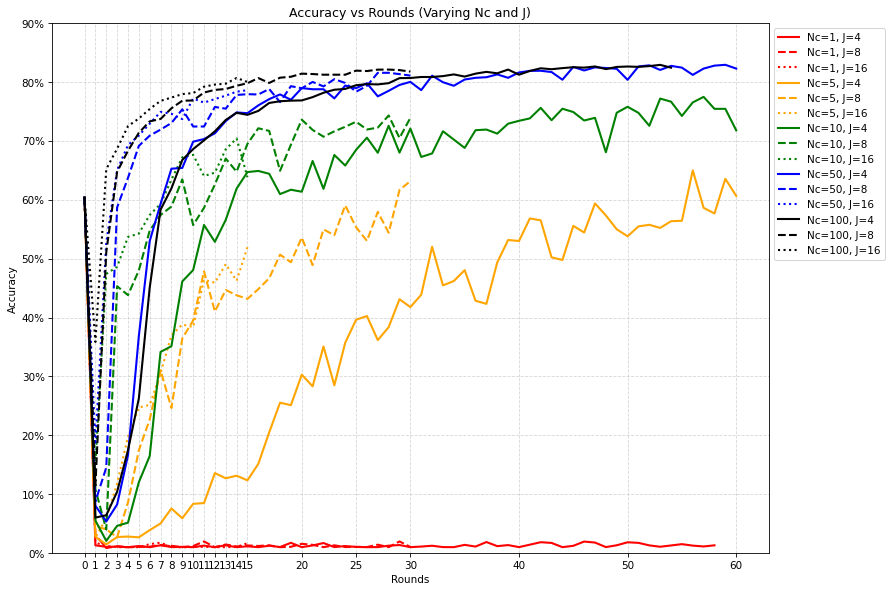

In [139]:
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Configuration
METRIC = "accuracy"
X_AXIS = "epoch"

# Dimensioni e dpi figura
width_px = 900
height_px = 600
dpi = 75

# Padding percentuale per l'asse X
x_padding = 0.05  # 5% di padding su ogni lato

# Define style mappings
colors = {1: "red", 5: "orange", 10: "green", 50: "blue", 100: "black"}
line_styles = {4: "-", 8: "--", 16: ":"}  # solid  # dashed  # dotted

# Troncamenti e passi xtick per J
max_epochs = {4: 60, 8: 30, 16: 15}
tick_steps = {4: 10, 8: 5, 16: 1}


# Function to extract Nc and J from the run group name
def parse_run_params(run_name):
    # Matches patterns like "...-nc100-j16..."
    match = re.search(r"nc(\d+)-j(\d+)", run_name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None


fig, ax = plt.subplots(figsize=(width_px / dpi, height_px / dpi), dpi=dpi)

# Identify all unique runs in the dataframe
run_names = df["run_name"].unique()

# Filter and sort runs to ensure the legend is logical
valid_runs = []
for r in run_names:
    nc, j = parse_run_params(r)
    # Only include if we found the params and they match our style keys
    if nc in colors and j in line_styles:
        valid_runs.append((nc, j, r))

# Sort by Nc, then by J
valid_runs.sort(key=lambda x: (x[0], x[1]))

# Precompute combined xticks to respect different J spacings
xticks = set()
for j, step in tick_steps.items():
    xticks.update(range(0, max_epochs[j] + 1, step))
xticks = sorted(xticks)

# Plot each run
for nc, j, r_name in valid_runs:
    subset = df[df["run_name"] == r_name].sort_values(X_AXIS)
    if subset.empty:
        continue
    # Assicura un punto iniziale a epoch 0 con valore fissato
    if (subset[X_AXIS] == 0).any():
        subset.loc[subset[X_AXIS] == 0, METRIC] = 0.6041
    else:
        start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": r_name}
        subset = pd.concat([pd.DataFrame([start_row]), subset], ignore_index=True)
    # Tronca in base al valore di J
    if j in max_epochs:
        subset = subset[subset[X_AXIS] <= max_epochs[j]]
    ax.plot(
        subset[X_AXIS],
        subset[METRIC],
        label=f"Nc={nc}, J={j}",
        color=colors[nc],
        linestyle=line_styles[j],
        linewidth=2,
    )

ax.set_title("Accuracy vs Rounds (Varying Nc and J)")
# Aggiungi padding proporzionale
max_x = max(max_epochs.values())
padding = max_x * x_padding
ax.set_xlim(-padding, max_x + padding)
ax.set_ylim(0, 0.9)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel("Rounds")
ax.set_ylabel("Accuracy")
ax.set_xticks(xticks)
ax.grid(True, linestyle="--", alpha=0.5)

ax.legend(bbox_to_anchor=(1.00, 1), loc="best")  # Move legend outside if crowded
plt.tight_layout()
plt.show()

# Task arithmetic

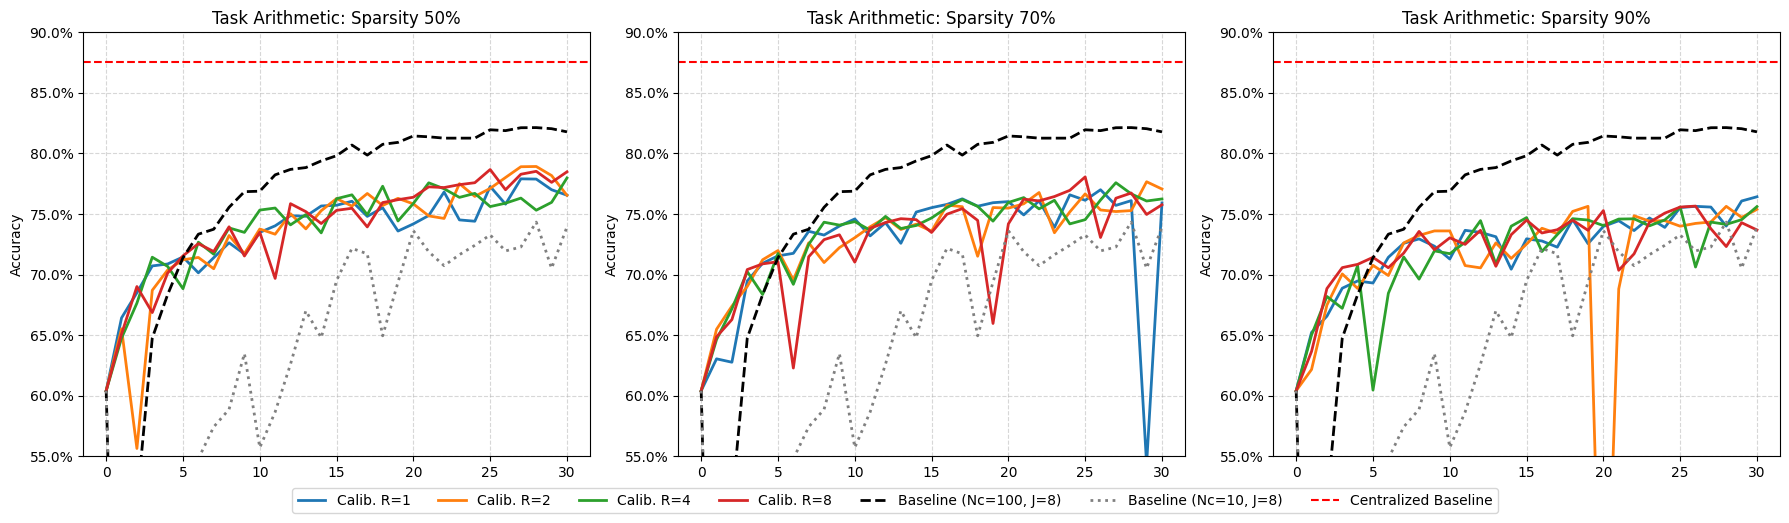

In [140]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Configuration
METRIC = "accuracy"
X_AXIS = "epoch"
CENTRALIZED_ACC = 0.8755

# 1. Define Group Names Mapping based on config files
# Structure: {sparsity: {rounds: 'wandb_group_name'}}
# Note: Inconsistencies in naming (e.g., 'V2-' prefix) are handled here.
ta_groups = {
    50: {
        1: "V2-task-arithmetic-s50-r1-V2",
        2: "V2-task-arithmetic-s50-r2-V2",
        4: "task-arithmetic-s50-r4-V2",
        8: "task-arithmetic-s50-r8-V2",
    },
    70: {
        1: "task-arithmetic-s70-r1-V2",
        2: "task-arithmetic-s70-r2",
        4: "task-arithmetic-s70-r4-V2",
        8: "task-arithmetic-s70-r8-V2",
    },
    90: {
        1: "task-arithmetic-s90-r1-V2",
        2: "task-arithmetic-s90-r2-V2",
        4: "task-arithmetic-s90-r4-V2",
        8: "task-arithmetic-s90-r8-V2",
    },
}

baseline_nc100 = "baseline-fedavg-nc100-j8"
baseline_nc10 = "baseline-fedavg-nc10-j8"

# Imposta dimensione in pixel e dpi
width_px = 1800
height_px = 500
dpi = 100

# Padding percentuale per l'asse X
x_padding = 0.05  # 5% di padding su ogni lato
max_rounds = 30

sparsities = [50, 70, 90]

# Crea 1 riga, 3 colonne
fig, axes = plt.subplots(1, len(sparsities), dpi=dpi)
fig.set_size_inches(width_px / dpi, height_px / dpi)

for idx, s in enumerate(sparsities):
    ax = axes[idx]
    ax.set_title(f"Task Arithmetic: Sparsity {s}%")

    # Plot Task Arithmetic runs
    for r, group_name in ta_groups[s].items():
        subset = df[df["run_name"] == group_name].sort_values(X_AXIS)
        if not subset.empty:
            # Assicura un punto iniziale a round 0 con valore fissato
            if (subset[X_AXIS] == 0).any():
                subset.loc[subset[X_AXIS] == 0, METRIC] = 0.6041
            else:
                start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": group_name}
                subset = pd.concat(
                    [pd.DataFrame([start_row]), subset], ignore_index=True
                )
            # Tronca a round 30
            subset = subset[subset[X_AXIS] <= 30]
            ax.plot(subset[X_AXIS], subset[METRIC], label=f"Calib. R={r}", linewidth=2)

    # Plot Baselines
    base100 = df[df["run_name"] == baseline_nc100].sort_values(X_AXIS)
    if not base100.empty:
        # Assicura punto iniziale baseline
        if (base100[X_AXIS] == 0).any():
            base100.loc[base100[X_AXIS] == 0, METRIC] = 0.6041
        else:
            start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": baseline_nc100}
            base100 = pd.concat([pd.DataFrame([start_row]), base100], ignore_index=True)
        # Tronca a round 30
        base100 = base100[base100[X_AXIS] <= 30]
        ax.plot(
            base100[X_AXIS],
            base100[METRIC],
            label="Baseline (Nc=100, J=8)",
            color="black",
            linestyle="--",
            linewidth=2,
        )

    base10 = df[df["run_name"] == baseline_nc10].sort_values(X_AXIS)
    if not base10.empty:
        # Assicura punto iniziale baseline
        if (base10[X_AXIS] == 0).any():
            base10.loc[base10[X_AXIS] == 0, METRIC] = 0.6041
        else:
            start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": baseline_nc10}
            base10 = pd.concat([pd.DataFrame([start_row]), base10], ignore_index=True)
        # Tronca a round 30
        base10 = base10[base10[X_AXIS] <= 30]
        ax.plot(
            base10[X_AXIS],
            base10[METRIC],
            label="Baseline (Nc=10, J=8)",
            color="grey",
            linestyle=":",
            linewidth=2,
        )

    ax.axhline(
        y=CENTRALIZED_ACC, color="red", linestyle="--", label="Centralized Baseline"
    )
    # Aggiungi padding proporzionale
    padding = max_rounds * x_padding
    ax.set_xlim(-padding, max_rounds + padding)
    ax.set_ylim(0.55, 0.9)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylabel("Accuracy")
    ax.grid(True, linestyle="--", alpha=0.5)

    # Mostra la leggenda una sola volta sotto tutta la figura
    if idx == len(sparsities) - 1:
        handles, labels = ax.get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc="lower center",
            ncol=7,
            bbox_to_anchor=(0.5, -0.05),
        )


plt.tight_layout()
plt.show()

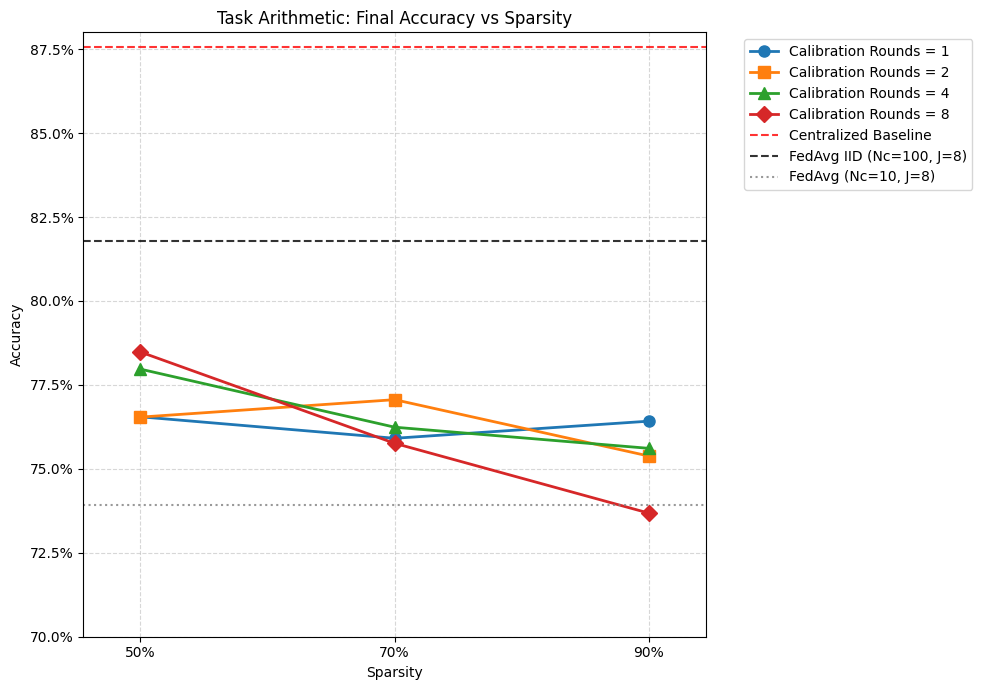

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import PercentFormatter

# Configuration
METRIC = "accuracy"
X_AXIS = "epoch"
CENTRALIZED_ACC = 0.8755
AVG_WINDOW = 0  # media sui round [30-AVG_WINDOW, 30]

# 1. Define Run Mapping (Sparsity -> Rounds -> Group Name)
ta_groups_config = {
    50: {
        1: "V2-task-arithmetic-s50-r1-V2",
        2: "V2-task-arithmetic-s50-r2-V2",
        4: "task-arithmetic-s50-r4-V2",
        8: "task-arithmetic-s50-r8-V2",
    },
    70: {
        1: "task-arithmetic-s70-r1-V2",
        2: "task-arithmetic-s70-r2",
        4: "task-arithmetic-s70-r4-V2",
        8: "task-arithmetic-s70-r8-V2",
    },
    90: {
        1: "task-arithmetic-s90-r1-V2",
        2: "task-arithmetic-s90-r2-V2",
        4: "task-arithmetic-s90-r4-V2",
        8: "task-arithmetic-s90-r8-V2",
    },
}

baselines = {
    "FedAvg IID (Nc=100, J=8)": "baseline-fedavg-nc100-j8",
    "FedAvg (Nc=10, J=8)": "baseline-fedavg-nc10-j8",
}

CENTRALIZED_ACC = 0.8755  # Fixed value

# 2. Extract average accuracy on [30-AVG_WINDOW, 30]
data = []

# Process Task Arithmetic runs
for sparsity, rounds_dict in ta_groups_config.items():
    for r, run_name in rounds_dict.items():
        # Get average accuracy on [30-AVG_WINDOW, 30] for this run
        run_data = df[
            (df["run_name"] == run_name)
            & (df[X_AXIS] >= 30 - AVG_WINDOW)
            & (df[X_AXIS] <= 30)
        ][METRIC]
        if not run_data.empty:
            max_acc = run_data.mean()
            data.append(
                {
                    "Sparsity": sparsity,
                    "Rounds": r,
                    "Accuracy": max_acc,
                    "Type": "Task Arithmetic",
                }
            )

# Process Baselines
baseline_vals = {}
for label, run_name in baselines.items():
    run_data = df[
        (df["run_name"] == run_name)
        & (df[X_AXIS] >= 30 - AVG_WINDOW)
        & (df[X_AXIS] <= 30)
    ][METRIC]
    if not run_data.empty:
        baseline_vals[label] = run_data.mean()
    else:
        baseline_vals[label] = None

# Create DataFrame for easier plotting
res_df = pd.DataFrame(data)

# 3. Plotting
# Imposta dimensione in pixel e dpi
width_px = 1000
height_px = 700
dpi = 100

# Padding percentuale per l'asse X
x_padding = 0.05  # 5% di padding su ogni lato
max_sparsity = 95

fig = plt.figure(figsize=(width_px / dpi, height_px / dpi), dpi=dpi)

# Plot lines for each Calibration Round count
rounds_options = sorted(res_df["Rounds"].unique())
markers = ["o", "s", "^", "D"]  # distinct markers for rounds

for i, r in enumerate(rounds_options):
    subset = res_df[res_df["Rounds"] == r].sort_values("Sparsity")
    plt.plot(
        subset["Sparsity"],
        subset["Accuracy"],
        marker=markers[i],
        linewidth=2,
        markersize=8,
        label=f"Calibration Rounds = {r}",
    )

# Plot Horizontal Baselines
colors = ["black", "grey"]
styles = ["--", ":"]

# Centralized
plt.axhline(
    y=CENTRALIZED_ACC,
    color="red",
    linestyle="--",
    label="Centralized Baseline",
    alpha=0.8,
)

# FedAvg Baselines
for i, (label, val) in enumerate(baseline_vals.items()):
    if val is not None:
        plt.axhline(
            y=val,
            color=colors[i],
            linestyle=styles[i],
            label=f"{label}",
            alpha=0.8,
        )

# Styling
plt.title("Task Arithmetic: Final Accuracy vs Sparsity")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
min_sparsity = min(sparsities)
max_sparsity_tick = max(sparsities)
padding = max_sparsity_tick * x_padding
plt.xlim(min_sparsity - padding, max_sparsity_tick + padding)

plt.xticks(sparsities, [f"{s}%" for s in sparsities])
plt.xlabel("Sparsity")

plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0.70, 0.88)

# Legend
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.show()

# Extension

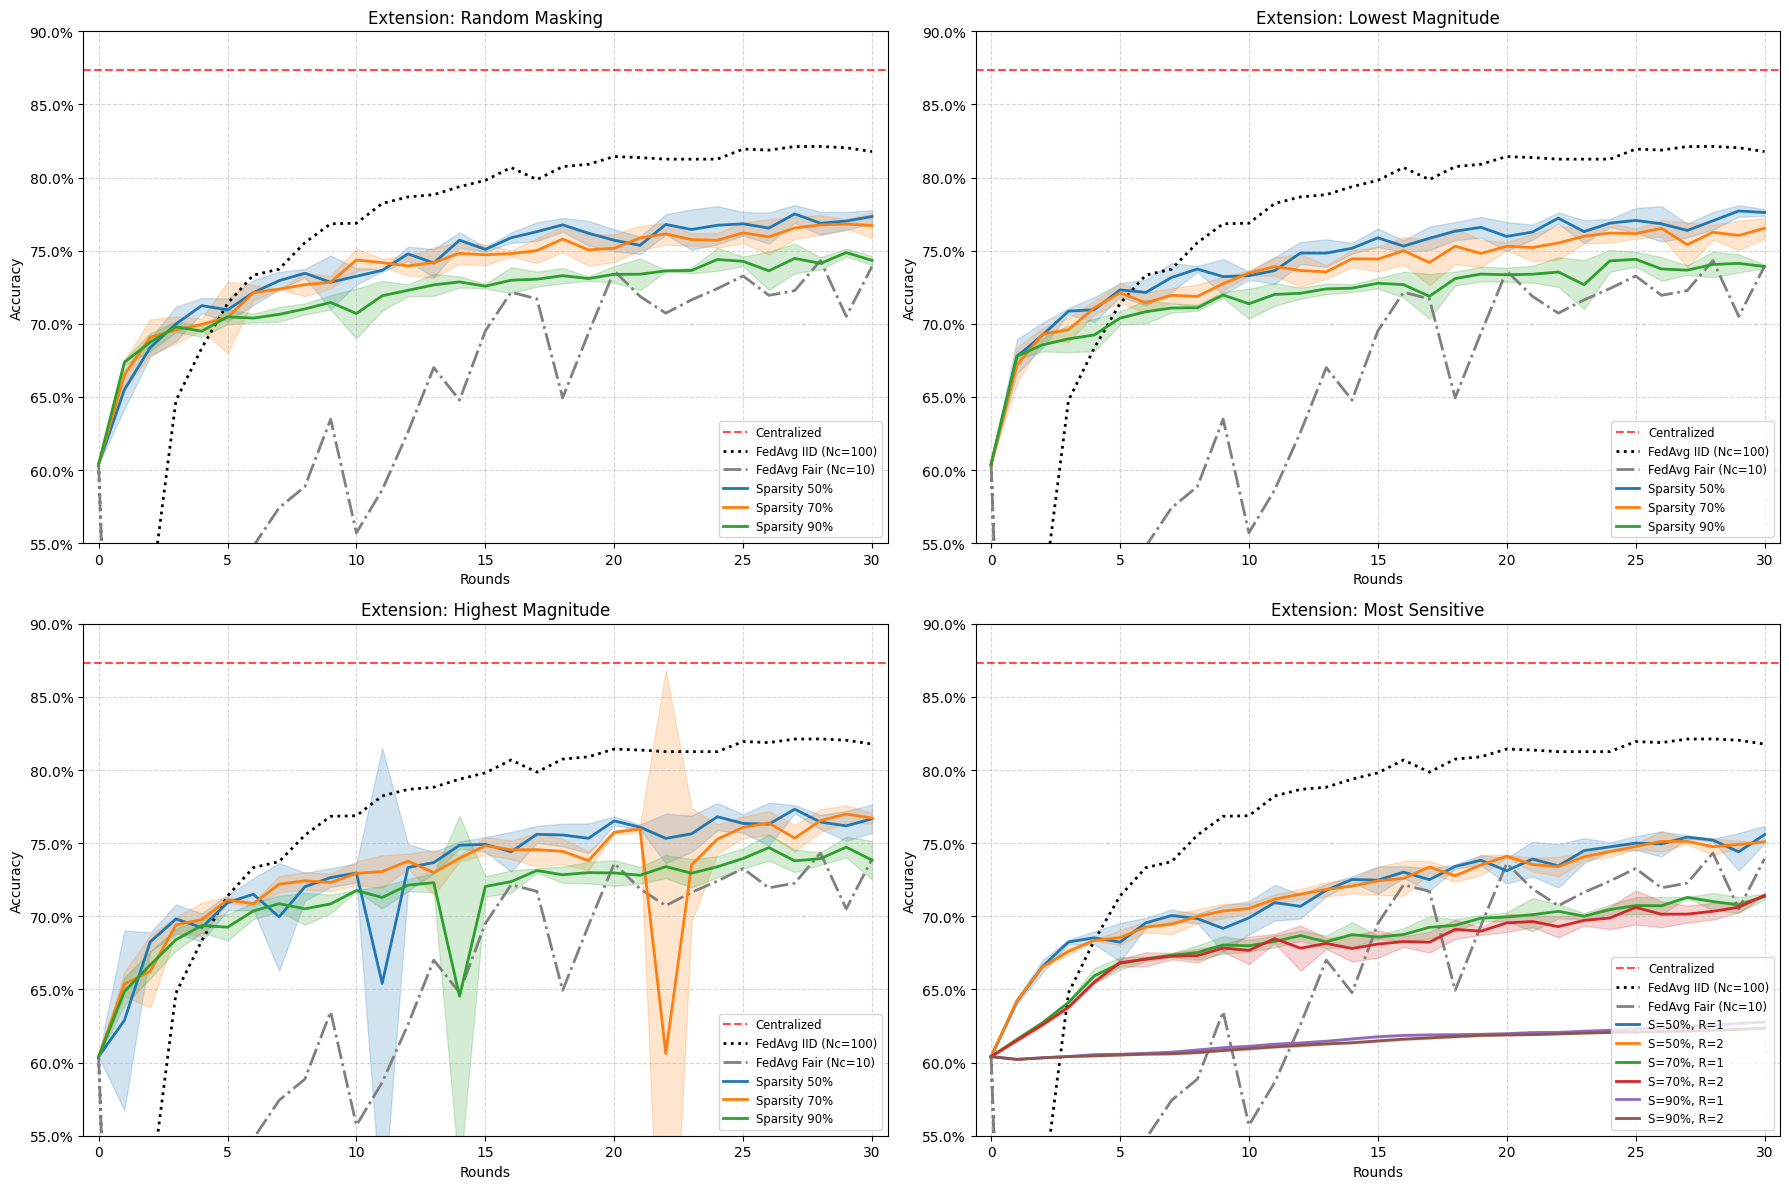

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import re
import numpy as np
from matplotlib.ticker import PercentFormatter

# --- Configuration & Constants ---
CENTRALIZED_ACC = 0.8733
METRIC = "accuracy"
X_AXIS = "epoch"

# Imposta dimensione in pixel e dpi
width_px = 1800
height_px = 1200
dpi = 100

# Padding percentuale per l'asse X
x_padding = 0.02
max_rounds = 30

# Define Baseline Groups
BASELINE_IID = "baseline-fedavg-nc100-j8"
BASELINE_FAIR = "baseline-fedavg-nc10-j8"
BEST_TA_GROUP = "task_arithmetic_s70_r8-V2"


# Helper function to normalize run names (remove -RUNx suffix)
def get_base_name(run_name):
    # Regex to remove -RUN1, -RUN2, etc. at the end
    return re.sub(r"-RUN\d+$", "", run_name)


# Create a 'base_name' column for aggregation
df["base_name"] = df["run_name"].apply(get_base_name)

# Pre-calculate aggregated data (mean & std) for all base_names
# Group by base_name and epoch
agg_df = df.groupby(["base_name", X_AXIS])[METRIC].agg(["mean", "std"]).reset_index()


# Function to plot a single extension chart
def plot_extension(extension_name, config_dict, ax, ylim=(0.6, 0.85)):
    # 1. Plot Baselines (Fixed for all charts)

    # Centralized
    ax.axhline(
        y=CENTRALIZED_ACC, color="red", linestyle="--", label="Centralized", alpha=0.7
    )

    # FedAvg IID
    iid_data = df[df["run_name"] == BASELINE_IID].sort_values(X_AXIS)
    if not iid_data.empty:
        # Assicura punto iniziale baseline
        if (iid_data[X_AXIS] == 0).any():
            iid_data.loc[iid_data[X_AXIS] == 0, METRIC] = 0.6041
        else:
            start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": BASELINE_IID}
            iid_data = pd.concat(
                [pd.DataFrame([start_row]), iid_data], ignore_index=True
            )
        # Tronca a round 30
        iid_data = iid_data[iid_data[X_AXIS] <= 30]
        ax.plot(
            iid_data[X_AXIS],
            iid_data[METRIC],
            color="black",
            linestyle=":",
            label="FedAvg IID (Nc=100)",
            linewidth=2,
        )

    # FedAvg Fair
    fair_data = df[df["run_name"] == BASELINE_FAIR].sort_values(X_AXIS)
    if not fair_data.empty:
        # Assicura punto iniziale baseline
        if (fair_data[X_AXIS] == 0).any():
            fair_data.loc[fair_data[X_AXIS] == 0, METRIC] = 0.6041
        else:
            start_row = {X_AXIS: 0, METRIC: 0.6041, "run_name": BASELINE_FAIR}
            fair_data = pd.concat(
                [pd.DataFrame([start_row]), fair_data], ignore_index=True
            )
        # Tronca a round 30
        fair_data = fair_data[fair_data[X_AXIS] <= 30]
        ax.plot(
            fair_data[X_AXIS],
            fair_data[METRIC],
            color="grey",
            linestyle="-.",
            label="FedAvg Fair (Nc=10)",
            linewidth=2,
        )

    # Best Task Arithmetic
    # Check if we need to aggregate or if it's a single run
    ta_base = get_base_name(BEST_TA_GROUP)
    ta_data = agg_df[agg_df["base_name"] == ta_base].sort_values(X_AXIS)
    if not ta_data.empty:
        # Tronca a round 30
        ta_data = ta_data[ta_data[X_AXIS] <= 30]
        ax.plot(
            ta_data[X_AXIS],
            ta_data["mean"],
            color="purple",
            linestyle="-",
            label="Best Task Arithmetic",
            linewidth=2,
        )

    # 2. Plot Extension Curves
    # Iterate through the specific configs for this extension
    for label, base_group in config_dict.items():
        subset = agg_df[agg_df["base_name"] == base_group].sort_values(X_AXIS)

        if not subset.empty:
            # Assicura punto iniziale a round 0 con valore fissato
            if (subset[X_AXIS] == 0).any():
                subset.loc[subset[X_AXIS] == 0, "mean"] = 0.6041
            else:
                start_row = {X_AXIS: 0, "mean": 0.6041, "std": 0}
                subset = pd.concat(
                    [pd.DataFrame([start_row]), subset], ignore_index=True
                )
            # Tronca a round 30
            subset = subset[subset[X_AXIS] <= 30]
            # Plot Mean Line
            (line,) = ax.plot(subset[X_AXIS], subset["mean"], label=label, linewidth=2)

            # Fill Standard Deviation
            ax.fill_between(
                subset[X_AXIS],
                subset["mean"] - subset["std"].fillna(0),
                subset["mean"] + subset["std"].fillna(0),
                color=line.get_color(),
                alpha=0.2,
            )

    # Formatting
    ax.set_title(f"Extension: {extension_name}")
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Accuracy")
    # Aggiungi padding proporzionale
    padding = max_rounds * x_padding
    ax.set_xlim(-padding, max_rounds + padding)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_ylim(ylim)
    ax.legend(fontsize="small", loc="lower right")


# --- Define Extension Configurations ---

# 1. Random Masking (Sparsity 50, 70, 90)
random_configs = {
    "Sparsity 50%": "random-masking-s50",
    "Sparsity 70%": "random-masking-s70",
    "Sparsity 90%": "random-masking-s90",
}

# 2. Lowest Magnitude (Sparsity 50, 70, 90)
low_mag_configs = {
    "Sparsity 50%": "lowest-magnitude-s50",
    "Sparsity 70%": "lowest-magnitude-s70",
    "Sparsity 90%": "lowest-magnitude-s90",
}

# 3. Highest Magnitude (Sparsity 50, 70, 90)
high_mag_configs = {
    "Sparsity 50%": "highest-magnitude-s50",
    "Sparsity 70%": "highest-magnitude-s70",
    "Sparsity 90%": "highest-magnitude-s90",
}

# 4. Most Sensitive (Sparsity 50/70/90 x Rounds 1/2)
# Note: Base names derived from config patterns (e.g., most-sensitive-s50-r1)
most_sens_configs = {
    "S=50%, R=1": "most-sensitive-s50-r1",
    "S=50%, R=2": "most-sensitive-s50-r2",
    "S=70%, R=1": "most-sensitive-s70-r1",
    "S=70%, R=2": "most-sensitive-s70-r2",
    "S=90%, R=1": "most-sensitive-s90-r1",
    "S=90%, R=2": "most-sensitive-s90-r2",
}

# --- Generate Plots ---
fig, axes = plt.subplots(2, 2, figsize=(width_px / dpi, height_px / dpi), dpi=dpi)

plot_extension("Random Masking", random_configs, axes[0, 0], ylim=(0.55, 0.9))
plot_extension("Lowest Magnitude", low_mag_configs, axes[0, 1], ylim=(0.55, 0.9))
plot_extension("Highest Magnitude", high_mag_configs, axes[1, 0], ylim=(0.55, 0.9))
plot_extension("Most Sensitive", most_sens_configs, axes[1, 1], ylim=(0.55, 0.9))

plt.tight_layout()
plt.show()